In [1]:
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries

# GPS time for GW150914
t_merger = 1126259462.4
window = 4

In [2]:
print("getting data ...")
data_H1 = TimeSeries.fetch_open_data('H1', t_merger-window, t_merger+window)
data_L1 = TimeSeries.fetch_open_data('L1', t_merger-window, t_merger+window)


getting data ...


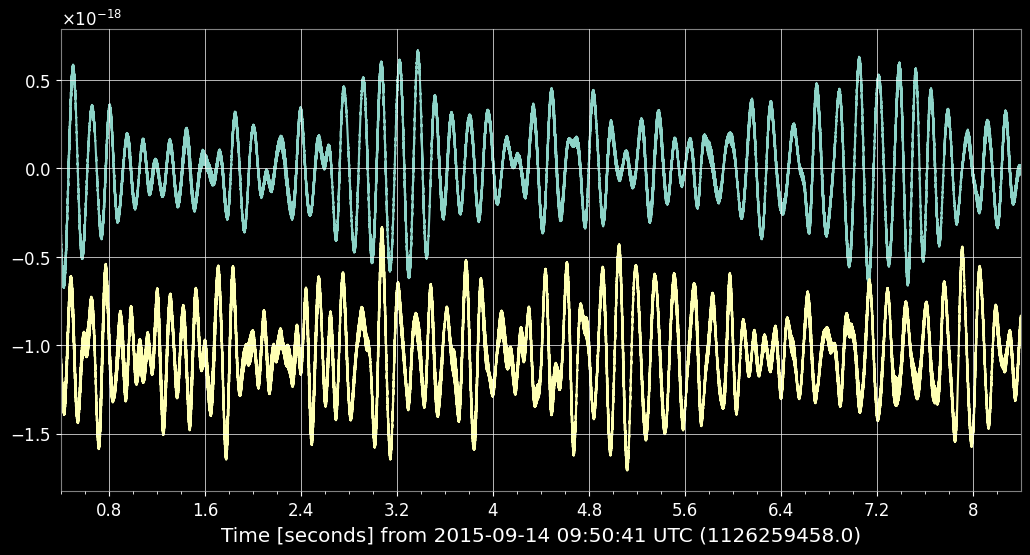

In [4]:
from gwpy.plot import Plot
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
plot = Plot(data_H1, data_L1, figsize= (12, 6))

In [7]:
wh1 = data_H1.whiten().bandpass(50, 300)
wl1 = data_L1.whiten().bandpass(50, 300)

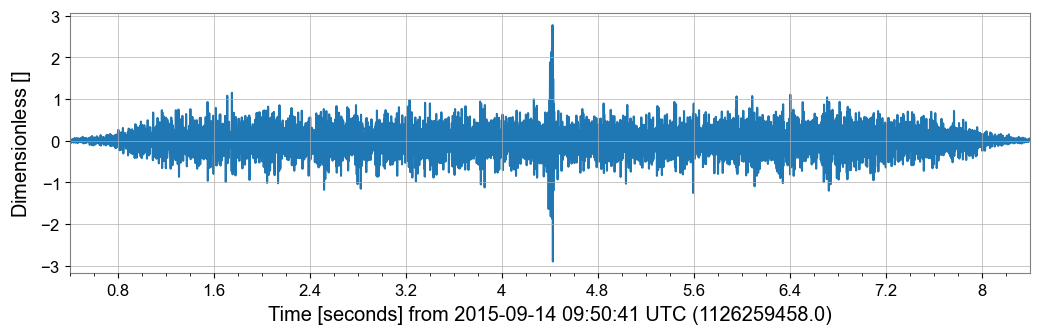

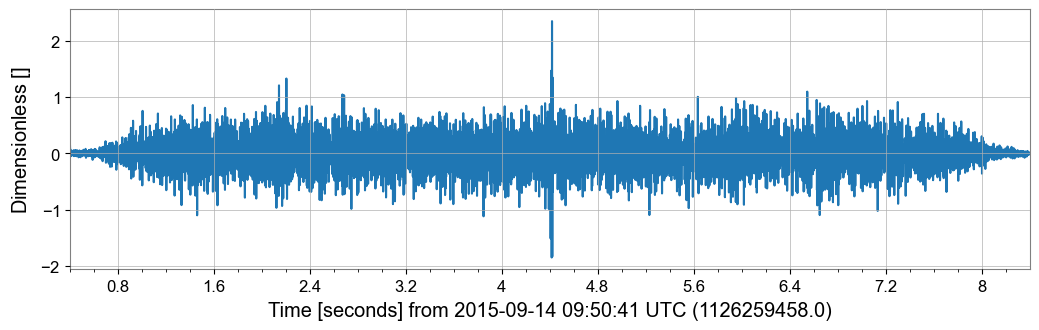

In [8]:
wh1_plot = wh1.plot()
wl1_plot = wl1.plot()

In [9]:
crop_h1 = wh1.crop(t_merger - 0.05, t_merger + 0.05)
crop_l1 = wl1.crop(t_merger - 0.05, t_merger + 0.05)

In [10]:
import numpy as np

correlation_between_l1_h1 = np.correlate(crop_h1.value, -crop_l1.value, mode='full')
lags = np.arange(len(correlation_between_l1_h1)) - (len(crop_h1) - 1)
dt_samples = lags[np.argmax(correlation_between_l1_h1)]
dt_seconds = dt_samples / data_H1.sample_rate.value
print(f"Measured time delay: {dt_seconds * 1000:.2f} ms")

Measured time delay: 7.32 ms


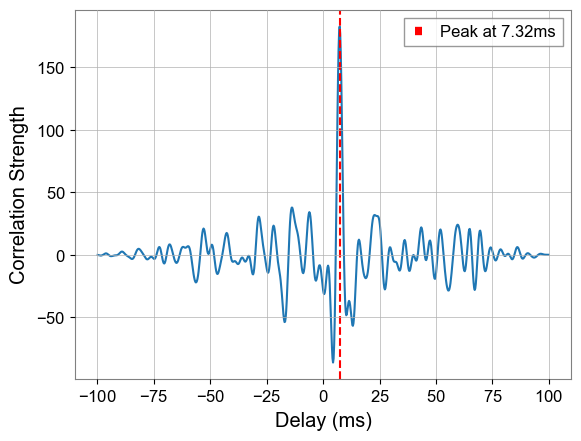

In [11]:
plt.plot(lags * (1000/data_H1.sample_rate.value), correlation_between_l1_h1)
plt.axvline(dt_seconds * 1000, color='red', linestyle='--', label=f'Peak at {dt_seconds*1000:.2f}ms')
plt.xlabel('Delay (ms)')
plt.ylabel('Correlation Strength')
plt.legend()
plt.show()

# Cross-Correlation for Time Delay Calculation

## Overview
This code calculates the time delay between two gravitational wave signals (L1 and H1 detectors) using cross-correlation.
```python
correlation_between_l1_h1 = np.correlate(crop_h1.value, -crop_l1.value, mode='full')
lags = np.arange(len(correlation_between_l1_h1)) - (len(crop_h1) - 1)
dt_samples = lags[np.argmax(correlation_between_l1_h1)]
dt_seconds = dt_samples / data_H1.sample_rate.value
```

---

## How Cross-Correlation Works

### Basic Concept
Cross-correlation measures the similarity between two signals at different time shifts (lags). It slides one signal across the other and calculates the sum of element-wise products at each position.

**Formula**: `Correlation(lag) = Σ (A[i] × B[i + lag])` for all overlapping indices

### Example Calculation
For signals `A = [1, 2, 3]` and `B = [4, 5, 6]`:

| Lag | Alignment                                    | Calculation       | Result |
|-----|----------------------------------------------|-------------------|--------|
| -2  | `[1,2,3]`<br>`[4,5,6]` (only last overlaps)  | `1×6`             | 6      |
| -1  | `[1,2,3]`<br>`[4,5,6]` (last 2 overlap)      | `1×5 + 2×6`       | 17     |
| 0   | `[1,2,3]`<br>`[4,5,6]` (fully aligned)       | `1×4 + 2×5 + 3×6` | **32** |
| +1  | `[1,2,3]`<br>`[4,5,6]` (first 2 overlap)     | `2×4 + 3×5`       | 23     |
| +2  | `[1,2,3]`<br>`[4,5,6]` (only first overlaps) | `3×4`             | 12     |

The maximum correlation (32) occurs at lag = 0, meaning signals are best aligned with no shift.

---

## Understanding `mode='full'`

With `mode='full'`, NumPy calculates correlation at **all possible overlaps**, including partial ones.

### Output Length
For signals of length N: **Output length = 2N - 1**

**Example**: If each signal has 5 samples:
- 4 positions with partial overlap (B shifted left)
- 1 position with full alignment
- 4 positions with partial overlap (B shifted right)
- **Total: 4 + 1 + 4 = 9 positions**

---

## Understanding the Lags Array
```python
lags = np.arange(len(correlation_between_l1_h1)) - (len(crop_h1) - 1)
```

This creates a **symmetric lag array centered at zero**.

### Example
If `crop_h1` has 5 samples:
- Correlation output length: `2×5 - 1 = 9`
- `np.arange(9)` gives: `[0, 1, 2, 3, 4, 5, 6, 7, 8]`
- Subtract `(5-1) = 4`: `[-4, -3, -2, -1, 0, 1, 2, 3, 4]`

### Interpretation
- **Negative lag**: Signal B arrives earlier (shifted left)
- **Zero lag**: Signals perfectly aligned
- **Positive lag**: Signal A arrives earlier (shifted right)

---

## Finding Time Delay
```python
dt_samples = lags[np.argmax(correlation_between_l1_h1)]
```

- `np.argmax()` finds the index where correlation is maximum
- This index corresponds to the lag where signals are best aligned
- The lag value tells us the time difference between detectors
```python
dt_seconds = dt_samples / data_H1.sample_rate.value
```

Converts the lag from samples to seconds using the sampling rate.

---

## Physical Interpretation

The time delay between detectors helps:
1. **Confirm detection**: Both detectors see the same signal
2. **Locate source**: Time difference constrains the sky position
3. **Validate alignment**: Accounts for detector orientations (hence `-crop_l1.value`)

The peak correlation occurs when the gravitational wave signals from both detectors are optimally aligned, accounting for light travel time between detector sites.

In [12]:
import numpy as np

A = np.array([1,2,3])
B = np.array([4,5,6])
correlationAB = np.correlate(A, B, mode='full')
print(correlationAB)

[ 6 17 32 23 12]
